# M5 — Prédiction des transactions à risque d'échec (LightGBM)

**Orange Money | Koceila SALEM**

Modèle **supervisé** : cible = `TRANSFER_STATUS == 'TF'` (échec). Le seul modèle
vraiment chiffrable du projet (label intégré, pas besoin de CRM).

## Choix méthodologiques (pour un vrai modèle métier validé)
- **Split TEMPOREL** : train 29/08→22/09, test 23/09→30/09 (reproduit la production)
- **EXCLUSION des features de fuite** : ERROR_CODE et ATTEMPT_STATUS sont des
  CONSÉQUENCES de l'échec (remplis seulement si échec) → fuite de données interdite
- **Déséquilibre** : géré automatiquement selon le taux de TF réel
- **Métriques honnêtes** : ROC-AUC + PR-AUC (classe rare) + matrice de confusion .
- **Checkpoints** : anti-crash RAM comme M1

## CELLULE 0 — Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json, time, warnings, gc
import lightgbm as lgb
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, classification_report)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

from src import config as cfg
from src.data_loader import load_parquet, load_columns, cast_numeric
from src.features import bloc_a_transaction, bloc_b_temporel, bloc_c_comportemental, bloc_d_contextuel

MODEL_DIR  = cfg.MODELS_DIR / 'M5_echec'
OUTPUT_DIR = cfg.OUTPUTS_DIR / 'M5_echec'
CKPT_DIR   = OUTPUT_DIR / '_checkpoints'
for d in (MODEL_DIR, OUTPUT_DIR, CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)
print('Imports OK | LightGBM', lgb.__version__)

Imports OK | LightGBM 4.6.0


## CELLULE 1 — Chargement + downcasting + features (checkpoint)

In [2]:
def downcast(df):
    for c in df.select_dtypes(include=['float64']).columns:
        df[c] = df[c].astype('float32')
    for c in df.select_dtypes(include=['object']).columns:
        if df[c].nunique()/len(df) < 0.5:
            df[c] = df[c].astype('category')
    return df

CKPT_FEAT = CKPT_DIR / 'features.parquet'

if CKPT_FEAT.exists():
    print('Checkpoint features trouvé -> rechargement')
    df = pd.read_parquet(CKPT_FEAT)
    print(f'Rechargé : {df.shape[0]:,} x {df.shape[1]}')
else:
    cols = load_columns('M5') + [cfg.COL_S_AVANT, cfg.COL_S_APRES,
           cfg.COL_R_AVANT, cfg.COL_R_APRES, cfg.COL_VILLE, cfg.COL_TAG]
    cols = list(dict.fromkeys(cols))
    df = load_parquet(columns=cols)
    df = cast_numeric(df)
    df = downcast(df)
    df = df.sort_values([cfg.COL_SENDER_ID, cfg.COL_DATE]).reset_index(drop=True)

    t = time.time()
    df = bloc_a_transaction.build(df)
    df = bloc_b_temporel.build(df)
    df = bloc_c_comportemental.build(df, verbose=True)
    df = bloc_d_contextuel.build(df)
    print(f'Features OK | {time.time()-t:.0f}s')

    # Downcast features
    for c in [c for c in df.columns if c.startswith('f_')]:
        if df[c].dtype=='float64': df[c]=df[c].astype('float32')
    df.to_parquet(CKPT_FEAT, index=False)
    print('Checkpoint sauvegardé')
gc.collect()

Checkpoint features trouvé -> rechargement
Rechargé : 25,456,467 x 68


20

## CELLULE 2 — Cible + EXCLUSION des features de fuite

**Crucial** : on retire ERROR_CODE et ATTEMPT_STATUS (conséquences de l'échec).

In [3]:
# CIBLE : 1 si échec (TF), 0 sinon
df['TARGET'] = (df[cfg.COL_STATUT] == 'TF').astype(int)
taux_tf = df['TARGET'].mean()
print(f'Taux d échec (TF) : {taux_tf*100:.2f}% ({df["TARGET"].sum():,} échecs)')

# Toutes les features f_*
all_feats = [c for c in df.columns if c.startswith('f_')]

# ══════════════════════════════════════════════════════════════
# EXCLUSION DES FEATURES DE FUITE (ÉTENDUE)
# ══════════════════════════════════════════════════════════════
# Une feature est une FUITE si sa valeur n'est connue qu'APRÈS la transaction
# ou si elle est une conséquence mécanique du succès/échec.
#
# 1. Statut / erreur / tentative : conséquences directes de l'échec
# 2. Soldes APRÈS (post_bal) : ne bougent pas si la tx échoue
#    -> delta_solde, incoherence, solde_apres_nul dérivent tous du post_bal
#
# On ne garde QUE les features connues AVANT la transaction :
#   montant, solde AVANT, heure, historique du compte, service, canal, ville
# ══════════════════════════════════════════════════════════════

# Groupe 1 : statut / erreur / tentative
fuite_statut = [c for c in all_feats if any(k in c for k in
                ['statut', 'has_error', 'attempt'])]

# Groupe 2 : tout ce qui dérive des soldes APRÈS transaction
fuite_solde = [c for c in all_feats if any(k in c for k in
               ['delta_solde', 'incoherence', 'solde_apres'])]

FUITE = sorted(set(fuite_statut + fuite_solde))
print(f'\nFeatures de FUITE exclues ({len(FUITE)}) :')
print('  -- statut/erreur (conséquence de l échec) :')
for f in fuite_statut: print(f'     - {f}')
print('  -- solde APRÈS transaction (ne bouge pas si échec) :')
for f in fuite_solde: print(f'     - {f}')

FEATURE_COLS = [c for c in all_feats if c not in FUITE]
print(f'\nFeatures retenues : {len(FEATURE_COLS)}')
print('Ces features sont toutes connues AVANT la transaction.')

# Features causales OK gardées explicitement notées
print('\nNote : f_taux_echec_hist gardée (causale, shift sur le passé)')
print('       f_log_solde_avant gardée (solde AVANT, connu a priori)')

Taux d échec (TF) : 5.81% (1,478,546 échecs)

Features de FUITE exclues (13) :
  -- statut/erreur (conséquence de l échec) :
     - f_statut_A1
     - f_statut_TF
     - f_statut_TI
     - f_statut_TPI
     - f_statut_TS
     - f_has_error
     - f_attempt_No Response
     - f_attempt_Request Cancelled
     - f_attempt_Request Confirmed
  -- solde APRÈS transaction (ne bouge pas si échec) :
     - f_delta_solde
     - f_log_incoherence
     - f_solde_apres_nul
     - f_incoherence_recvr

Features retenues : 36
Ces features sont toutes connues AVANT la transaction.

Note : f_taux_echec_hist gardée (causale, shift sur le passé)
       f_log_solde_avant gardée (solde AVANT, connu a priori)


## CELLULE 3 — Split TEMPOREL (pas aléatoire)

In [4]:
# Date de coupure : 23/09 (≈ 78% train / 22% test)
DATE_SPLIT = pd.Timestamp('2025-09-23')

mask_train = df[cfg.COL_DATE] < DATE_SPLIT
mask_test  = df[cfg.COL_DATE] >= DATE_SPLIT

X_train = df.loc[mask_train, FEATURE_COLS].fillna(0)
y_train = df.loc[mask_train, 'TARGET']
X_test  = df.loc[mask_test, FEATURE_COLS].fillna(0)
y_test  = df.loc[mask_test, 'TARGET']

print(f'Train : {len(X_train):,} lignes (29/08 → 22/09) | TF = {y_train.mean()*100:.2f}%')
print(f'Test  : {len(X_test):,} lignes (23/09 → 30/09) | TF = {y_test.mean()*100:.2f}%')
gc.collect()

Train : 18,964,717 lignes (29/08 → 22/09) | TF = 5.69%
Test  : 6,491,750 lignes (23/09 → 30/09) | TF = 6.15%


0

## CELLULE 4 — Gestion du déséquilibre (selon taux réel) + entraînement

In [5]:
# Choix automatique selon le taux de TF
ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f'Ratio négatifs/positifs : {ratio:.1f}')

params = dict(cfg.LIGHTGBM_PARAMS)
if taux_tf < 0.02:
    # Déséquilibre sévère -> scale_pos_weight
    params.pop('class_weight', None)
    params['scale_pos_weight'] = ratio
    print(f'Déséquilibre sévère -> scale_pos_weight = {ratio:.1f}')
else:
    params['class_weight'] = 'balanced'
    print('Déséquilibre modéré -> class_weight=balanced')

t = time.time()
model = lgb.LGBMClassifier(**params)
for c in FEATURE_COLS:
    if not pd.api.types.is_numeric_dtype(X_train[c]):
        X_train[c] = pd.to_numeric(X_train[c], errors='coerce')
        X_test[c]  = pd.to_numeric(X_test[c],  errors='coerce')
X_train = X_train.astype('float32'); X_test = X_test.astype('float32')
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          eval_metric='auc',
          callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)])
print(f'Entraîné en {time.time()-t:.0f}s')

Ratio négatifs/positifs : 16.6
Déséquilibre modéré -> class_weight=balanced
[LightGBM] [Info] Number of positive: 1079134, number of negative: 17885583
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.618309 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3637
[LightGBM] [Info] Number of data points in the train set: 18964717, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 30 rounds
[50]	valid_0's auc: 0.949346
[100]	valid_0's auc: 0.952826
[150]	valid_0's auc: 0.954536
[200]	valid_0's auc: 0.955747
[250]	valid_0's auc: 0.956814
[300]	valid_0's auc: 0.957907
[350]	valid_0's auc: 0.958352
[400]	valid_0's auc: 0.958779
[450]	valid_0's auc: 0.9593
[500]	valid_0's auc: 0.959571
Did not meet early stopping. Best iteration is:
[496]	valid_0's 

## CELLULE 5 — Évaluation (métriques honnêtes)

In [6]:
y_proba = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)
print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}  (plus honnête sur classe rare)')

# ALERTE FUITE : si AUC trop élevé, suspecter une fuite
if roc_auc > 0.97:
    print('\n⚠️  AUC très élevé (>0.97) -> VÉRIFIER qu il n y a pas de fuite résiduelle !')
else:
    print('\n✅ AUC réaliste -> pas de signe de fuite évidente')

# Seuil optimal (maximise F1)
prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1 = 2*prec*rec/(prec+rec+1e-9)
seuil_opt = thr[np.argmax(f1[:-1])]
y_pred = (y_proba >= seuil_opt).astype(int)
print(f'\nSeuil optimal (F1) : {seuil_opt:.3f}')
print('\nMatrice de confusion :')
print(confusion_matrix(y_test, y_pred))
print('\n', classification_report(y_test, y_pred, target_names=['Succès','Échec']))

ROC-AUC : 0.9597
PR-AUC  : 0.8859  (plus honnête sur classe rare)

✅ AUC réaliste -> pas de signe de fuite évidente

Seuil optimal (F1) : 0.808

Matrice de confusion :
[[6078913   13425]
 [  75938  323474]]

               precision    recall  f1-score   support

      Succès       0.99      1.00      0.99   6092338
       Échec       0.96      0.81      0.88    399412

    accuracy                           0.99   6491750
   macro avg       0.97      0.90      0.94   6491750
weighted avg       0.99      0.99      0.99   6491750



## CELLULE 6 — Courbes ROC & PR + importance

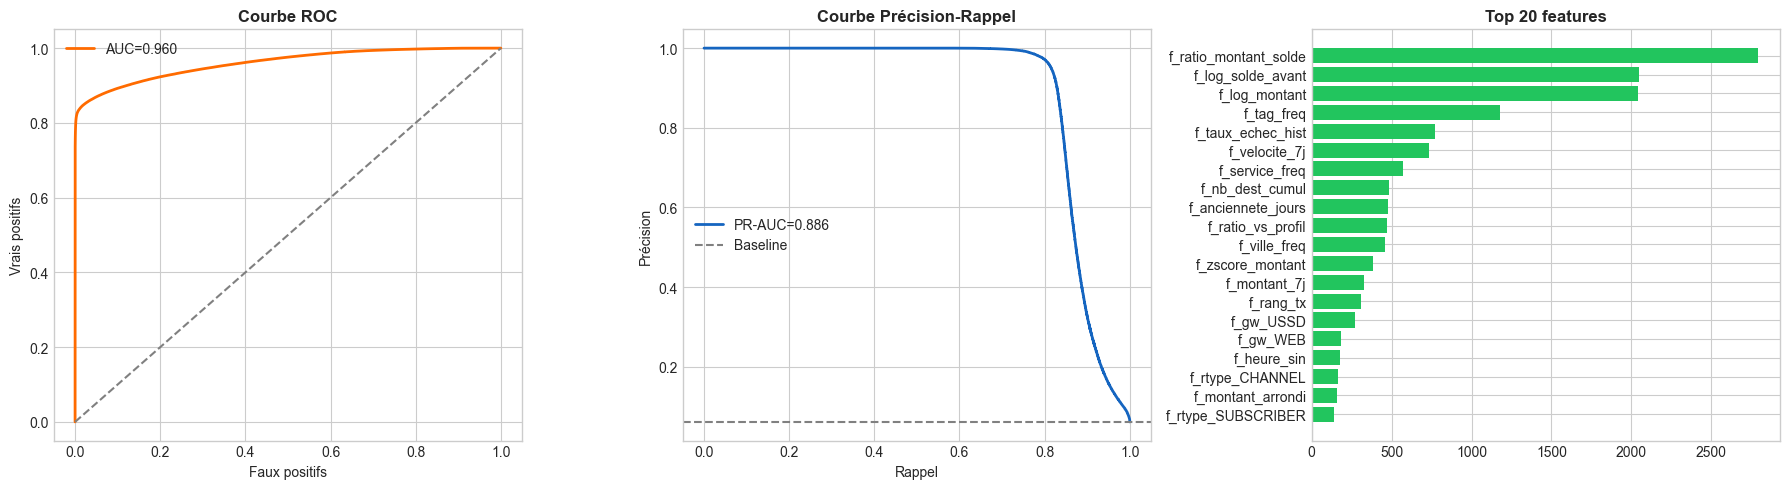

Top 10 features prédictives :
              feature  importance
f_ratio_montant_solde        2790
    f_log_solde_avant        2048
        f_log_montant        2039
           f_tag_freq        1179
    f_taux_echec_hist         770
        f_velocite_7j         737
       f_service_freq         574
      f_nb_dest_cumul         483
   f_anciennete_jours         475
    f_ratio_vs_profil         471


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#FF6B00', lw=2, label=f'AUC={roc_auc:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray')
axes[0].set_title('Courbe ROC', fontweight='bold'); axes[0].legend()
axes[0].set_xlabel('Faux positifs'); axes[0].set_ylabel('Vrais positifs')

# PR
axes[1].plot(rec, prec, color='#1565C0', lw=2, label=f'PR-AUC={pr_auc:.3f}')
axes[1].axhline(y_test.mean(), ls='--', color='gray', label='Baseline')
axes[1].set_title('Courbe Précision-Rappel', fontweight='bold'); axes[1].legend()
axes[1].set_xlabel('Rappel'); axes[1].set_ylabel('Précision')

# Importance
imp = pd.DataFrame({'feature': FEATURE_COLS,
                    'importance': model.feature_importances_}).sort_values('importance', ascending=False)
top = imp.head(20)
axes[2].barh(top['feature'][::-1], top['importance'][::-1], color='#22C55E')
axes[2].set_title('Top 20 features', fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'m5_eval.png', dpi=150); plt.show()

print('Top 10 features prédictives :')
print(imp.head(10).to_string(index=False))

## CELLULE 7 — Analyse des causes d'échec par service

In [8]:
# Taux d'échec réel par service (sur tout le dataset)
echec_svc = df.groupby(cfg.COL_SERVICE, observed=True)['TARGET'].agg(['mean','sum','count'])
echec_svc.columns = ['taux_echec','nb_echecs','nb_total']
echec_svc = echec_svc.sort_values('taux_echec', ascending=False)
echec_svc['taux_echec'] = (echec_svc['taux_echec']*100).round(2)
print('Taux d échec par service :')
print(echec_svc.to_string())

Taux d échec par service :
              taux_echec  nb_echecs  nb_total
SERVICE_TYPE                                 
COUTBYCODE        100.00        183       183
ENT2UNREG         100.00          1         1
ENT2UNPASS        100.00          7         7
CASHOUT            10.06     435249   4325031
B2BCASHOUT          7.57        344      4546
P2P                 7.25     211857   2922121
RC                  5.80     462650   7973510
MERCHPAY            5.02     302787   6028266
OPTW                4.31         27       626
ENT2REG             3.15        366     11630
O2C                 3.12         20       642
CASHIN              1.59      64991   4087453
TXNCORRECT          0.21         64     30753
DELSCR              0.00          0       201
ROLLBACK            0.00          0     71495
STOCK               0.00          0         2


## CELLULE 8 — Export (prêt pour inférence)

In [9]:
model.booster_.save_model(str(MODEL_DIR/'lightgbm.txt'))
joblib.dump(model, MODEL_DIR/'lightgbm.pkl')

params_save = {
    'FEATURE_COLS': FEATURE_COLS,
    'n_features': len(FEATURE_COLS),
    'features_fuite_exclues': FUITE,
    'date_split': str(DATE_SPLIT.date()),
    'seuil_optimal': float(seuil_opt),
    'roc_auc': float(roc_auc), 'pr_auc': float(pr_auc),
    'taux_tf': float(taux_tf),
    'lgb_params': {k:str(v) for k,v in params.items()},
}
with open(MODEL_DIR/'params.json','w') as f:
    json.dump(params_save, f, indent=2, default=str)

# Scorer tout le dataset (proba d'échec) pour le dashboard
df['PROBA_ECHEC'] = model.predict_proba(df[FEATURE_COLS].fillna(0))[:, 1]
id_cols = [cfg.COL_TRANSFER_ID, cfg.COL_DATE, cfg.COL_SENDER_ID,
           cfg.COL_MONTANT, cfg.COL_SERVICE, cfg.COL_STATUT]
id_cols = [c for c in id_cols if c in df.columns]
df[id_cols + ['TARGET','PROBA_ECHEC']].to_parquet(OUTPUT_DIR/'scored.parquet', index=False)

print('Exports créés :')
print('  models/M5_echec/  : lightgbm.pkl, lightgbm.txt, params.json')
print('  outputs/M5_echec/ : scored.parquet')
print(f'\n=== RÉSUMÉ M5 ===')
print(f'ROC-AUC      : {roc_auc:.4f}')
print(f'PR-AUC       : {pr_auc:.4f}')
print(f'Features     : {len(FEATURE_COLS)} (fuite exclue)')
print(f'Validation   : split temporel 23/09')

Exports créés :
  models/M5_echec/  : lightgbm.pkl, lightgbm.txt, params.json
  outputs/M5_echec/ : scored.parquet

=== RÉSUMÉ M5 ===
ROC-AUC      : 0.9597
PR-AUC       : 0.8859
Features     : 36 (fuite exclue)
Validation   : split temporel 23/09
